# TCN-MLP Model Deployment for Crop Yield Prediction

## Objective
Deploy a hybrid TCN-MLP (Temporal Convolutional Network + Multi-Layer Perceptron) architecture that combines:
- **TCN Branch**: Captures long-range temporal dependencies using dilated causal convolutions
- **MLP Branch**: Handles categorical features (Region, Crop) via embeddings

**Model**: Hybrid temporal + categorical sequence-to-scalar regression  
**Expected Performance**: R² ≥ 0.90, MAE < 0.20 (dependent on data distribution)  
**Advantages**: Parallelizable, no vanishing gradients, fewer parameters than LSTM

**Overfitting Prevention Strategies**:
- Dilated convolutions with residual blocks
- Dropout at multiple levels (TCN, MLP, merged layers)
- L2 regularization on all kernels and embeddings
- Early stopping with ReduceLROnPlateau
- Temporal cross-validation

In [1]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, Model, regularizers, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import json

# Set random seeds
np.random.seed(42)
tf.random.set_seed(42)

# Create directories
os.makedirs('models', exist_ok=True)
os.makedirs('results', exist_ok=True)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")
print("✓ Environment configured successfully")

c:\Users\ibito\anaconda3\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


TensorFlow version: 2.20.0
GPU Available: []
✓ Environment configured successfully


## 1. Data Loading & Feature Preparation

In [2]:
try:
    df = pd.read_csv('project_data/processed_data/master_data_hybrid.csv')
    print(f"Loaded data shape: {df.shape}")
except:
    print("Creating synthetic data for demonstration...")
    np.random.seed(42)
    n_samples = 3500
    df = pd.DataFrame({
        'Region': np.random.choice(['North', 'South', 'East', 'West'], n_samples),
        'Crop': np.random.choice(['Maize', 'Rice', 'Cassava', 'Yam'], n_samples),
        'Year': np.random.randint(2015, 2024, n_samples),
        'Month': np.random.randint(1, 13, n_samples),
        'Temperature_C': np.random.uniform(20, 35, n_samples),
        'Rainfall_mm': np.random.uniform(0, 300, n_samples),
        'Humidity_percent': np.random.uniform(40, 95, n_samples),
        'CO2_ppm': np.random.uniform(350, 450, n_samples),
        'Avg_pH': np.random.uniform(5.5, 7.5, n_samples),
        'Avg_Nitrogen_ppm': np.random.uniform(20, 200, n_samples),
        'Avg_Phosphorus_ppm': np.random.uniform(5, 50, n_samples),
        'GDD': np.random.uniform(500, 2500, n_samples),
        'Cumulative_Rainfall': np.random.uniform(100, 2000, n_samples),
        'Days_Into_Season': np.random.randint(1, 365, n_samples),
        'Heat_Stress': np.random.choice([0, 1], n_samples),
        'Drought_Risk': np.random.choice([0, 1], n_samples),
        'Yield_kg_per_ha': np.random.uniform(500, 8000, n_samples)
    })

print(f"Data shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nData info:")
print(df.info())
print(f"\nFirst few rows:")
print(df.head())

Loaded data shape: (3456, 35)
Data shape: (3456, 35)
Columns: ['Region', 'Crop', 'Year', 'Month', 'Temperature_C', 'Rainfall_mm', 'Humidity_percent', 'CO2_ppm', 'Avg_pH', 'Avg_Nitrogen_ppm', 'Avg_Phosphorus_ppm', 'Avg_Organic_Matter_Percent', 'Yield_kg_per_ha', 'GDD', 'Cumulative_Rainfall', 'Days_Into_Season', 'pH_Temperature_Interaction', 'Nitrogen_Rainfall_Interaction', 'Is_Rainy_Season', 'Is_Peak_Growing', 'Heat_Stress', 'Cold_Stress', 'Rainfall_Anomaly', 'Drought_Risk', 'Flood_Risk', 'Yield_Lag_1', 'Yield_Lag_2', 'Yield_Lag_3', 'Yield_MA_3yr', 'Temp_MA_3yr', 'Rain_MA_3yr', 'Yield_YoY_Change', 'Temp_YoY_Change', 'Rain_YoY_Change', 'Yield_Volatility_3yr']

Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3456 entries, 0 to 3455
Data columns (total 35 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Region                         3456 non-null   object 
 1   Crop                          

## 2. Encode Categoricals & Create Sequences

In [3]:
# Define feature groups
cat_features = ['Region', 'Crop']
num_features = ['Temperature_C', 'Rainfall_mm', 'Humidity_percent', 'CO2_ppm',
                 'Avg_pH', 'Avg_Nitrogen_ppm', 'Avg_Phosphorus_ppm', 'GDD',
                 'Cumulative_Rainfall', 'Days_Into_Season', 'Heat_Stress', 'Drought_Risk']
target = 'Yield_kg_per_ha'

# Ensure we have these columns
for col in cat_features + num_features + [target]:
    if col not in df.columns:
        if col in cat_features:
            df[col] = np.random.choice(['A', 'B'], len(df))
        else:
            df[col] = np.random.uniform(0, 100, len(df))

# Sort by Region, Crop, Year, Month for proper sequencing
df = df.sort_values(['Region', 'Crop', 'Year', 'Month']).reset_index(drop=True)

# Encode categoricals
encoders = {}
for col in cat_features:
    encoders[col] = LabelEncoder()
    df[f'{col}_enc'] = encoders[col].fit_transform(df[col].astype(str))

cat_dims = [df[f'{col}_enc'].max() + 1 for col in cat_features]
print(f"Categorical dimensions: {dict(zip(cat_features, cat_dims))}")

# Normalize numerical features
scaler_X = StandardScaler()
scaler_y = StandardScaler()
df[num_features] = scaler_X.fit_transform(df[num_features])
df[[target]] = scaler_y.fit_transform(df[[target]])

print(f"\n✓ Feature preparation complete")
print(f"  Numerical features: {len(num_features)}")
print(f"  Categorical features: {len(cat_features)}")

Categorical dimensions: {'Region': 6, 'Crop': 2}

✓ Feature preparation complete
  Numerical features: 12
  Categorical features: 2


In [4]:
# Create sequences for each Region-Crop group
def create_sequences(group, lookback, num_cols, cat_cols, target_col):
    X_num, X_cat, y = [], [], []
    num_values = group[num_cols].values
    cat_values = group[[f'{c}_enc' for c in cat_cols]].values
    y_values = group[target_col].values
    
    for i in range(lookback, len(group)):
        X_num.append(num_values[i-lookback:i])
        X_cat.append(cat_values[i])  # Use categorical from current timestep
        y.append(y_values[i])
    
    return np.array(X_num), np.array(X_cat), np.array(y)

lookback = 12
X_num_all, X_cat_all, y_all = [], [], []

for (region, crop), group in df.groupby(['Region', 'Crop']):
    X_num, X_cat, y = create_sequences(group, lookback, num_features, cat_features, target)
    X_num_all.append(X_num)
    X_cat_all.append(X_cat)
    y_all.append(y)

X_num_all = np.vstack(X_num_all)
X_cat_all = np.vstack(X_cat_all)
y_all = np.hstack(y_all)

print(f"Sequence data shapes:")
print(f"  X_num: {X_num_all.shape} (samples, timesteps, features)")
print(f"  X_cat: {X_cat_all.shape} (samples, cats)")
print(f"  y: {y_all.shape}")

# Train/Val/Test split (70-15-15) with temporal ordering
n = len(y_all)
train_idx = int(0.70 * n)
val_idx = int(0.85 * n)

X_num_train = X_num_all[:train_idx]
X_cat_train = X_cat_all[:train_idx]
y_train = y_all[:train_idx]

X_num_val = X_num_all[train_idx:val_idx]
X_cat_val = X_cat_all[train_idx:val_idx]
y_val = y_all[train_idx:val_idx]

X_num_test = X_num_all[val_idx:]
X_cat_test = X_cat_all[val_idx:]
y_test = y_all[val_idx:]

print(f"\nTrain/Val/Test split:")
print(f"  Train: {len(y_train)} samples")
print(f"  Val:   {len(y_val)} samples")
print(f"  Test:  {len(y_test)} samples")

Sequence data shapes:
  X_num: (3312, 12, 12) (samples, timesteps, features)
  X_cat: (3312, 2) (samples, cats)
  y: (3312,)

Train/Val/Test split:
  Train: 2318 samples
  Val:   497 samples
  Test:  497 samples


## 3. Build TCN-MLP Architecture

In [5]:
def build_tcn_mlp(lookback,
                  num_numeric,
                  cat_dims,
                  embed_dim=8,
                  tcn_filters=64,
                  tcn_kernel_size=3,
                  tcn_blocks=3,
                  tcn_dropout=0.2,
                  mlp_hidden_units=[32],
                  mlp_dropout=0.2,
                  dense_units=[64, 32],
                  dense_dropout=0.3,
                  l2_reg=1e-4):
    """
    Build TCN-MLP model.
    
    Parameters:
        lookback: sequence length
        num_numeric: number of numerical features per timestep
        cat_dims: list of vocabulary sizes for categorical features
        embed_dim: embedding dimension per categorical
        tcn_filters: number of filters in TCN convolutions
        tcn_blocks: number of residual blocks
    """
    
    # Inputs
    seq_input = layers.Input(shape=(lookback, num_numeric), name='sequence')
    cat_inputs = [layers.Input(shape=(1,), dtype=tf.int32, name=f'cat_{i}') for i in range(len(cat_dims))]
    
    # ===== TCN Branch =====
    def residual_block(x, dilation_rate, filters, kernel_size, dropout_rate):
        shortcut = x
        # First dilated conv
        x = layers.Conv1D(filters, kernel_size, padding='causal', dilation_rate=dilation_rate,
                          kernel_regularizer=regularizers.l2(l2_reg))(x)
        x = layers.Activation('relu')(x)
        x = layers.Dropout(dropout_rate)(x)
        # Second dilated conv
        x = layers.Conv1D(filters, kernel_size, padding='causal', dilation_rate=dilation_rate,
                          kernel_regularizer=regularizers.l2(l2_reg))(x)
        x = layers.Activation('relu')(x)
        x = layers.Dropout(dropout_rate)(x)
        # Adjust shortcut if needed
        if shortcut.shape[-1] != filters:
            shortcut = layers.Conv1D(filters, 1, padding='same',
                                    kernel_regularizer=regularizers.l2(l2_reg))(shortcut)
        x = layers.Add()([x, shortcut])
        x = layers.Activation('relu')(x)
        return x
    
    tcn_x = seq_input
    for i in range(tcn_blocks):
        dilation_rate = 2 ** i  # 1, 2, 4, 8, ...
        tcn_x = residual_block(tcn_x, dilation_rate, tcn_filters, tcn_kernel_size, tcn_dropout)
    
    # Global average pooling
    tcn_out = layers.GlobalAveragePooling1D()(tcn_x)
    
    # ===== MLP Branch (Categoricals) =====
    emb_vectors = []
    for i, (inp, dim) in enumerate(zip(cat_inputs, cat_dims)):
        emb = layers.Embedding(dim, embed_dim, embeddings_regularizer=regularizers.l2(l2_reg))(inp)
        emb = layers.Flatten()(emb)
        emb_vectors.append(emb)
    
    if len(emb_vectors) > 1:
        cat_concat = layers.Concatenate()(emb_vectors)
    else:
        cat_concat = emb_vectors[0]
    
    mlp_x = cat_concat
    for units in mlp_hidden_units:
        mlp_x = layers.Dense(units, activation='relu', kernel_regularizer=regularizers.l2(l2_reg))(mlp_x)
        mlp_x = layers.Dropout(mlp_dropout)(mlp_x)
    mlp_out = mlp_x
    
    # ===== Merge Branches =====
    combined = layers.Concatenate()([tcn_out, mlp_out])
    z = combined
    for units in dense_units:
        z = layers.Dense(units, activation='relu', kernel_regularizer=regularizers.l2(l2_reg))(z)
        z = layers.Dropout(dense_dropout)(z)
    output = layers.Dense(1, kernel_regularizer=regularizers.l2(l2_reg))(z)
    
    # Build model
    model = Model(inputs=[seq_input] + cat_inputs, outputs=output)
    return model

# Build model
model = build_tcn_mlp(lookback, len(num_features), cat_dims,
                     embed_dim=8, tcn_filters=64, tcn_blocks=3, tcn_dropout=0.2,
                     mlp_hidden_units=[32], mlp_dropout=0.2,
                     dense_units=[64, 32], dense_dropout=0.3, l2_reg=1e-4)

model.summary()
print(f"\n✓ Model built with {model.count_params():,} parameters")

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sequence            │ (None, 12, 12)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 12, 64)    │      2,368 │ sequence[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 12, 64)    │          0 │ conv1d[0][0]      │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 12, 64)    │          0 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 12, 64)    │     12,352 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 12, 64)    │          0 │ conv1d_1[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 12, 64)    │          0 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 12, 64)    │        832 │ sequence[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 12, 64)    │          0 │ dropout_1[0][0],  │
│                     │                   │            │ conv1d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 12, 64)    │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 12, 64)    │     12,352 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 12, 64)    │          0 │ conv1d_3[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 12, 64)    │          0 │ activation_3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 12, 64)    │     12,352 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 12, 64)    │          0 │ conv1d_4[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 12, 64)    │          0 │ activation_4[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 12, 64)    │          0 │ dropout_3[0][0],  │
│                     │                   │            │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_5        │ (None, 12, 64)    │          0 │ add_1[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 12, 64)    │     12,352 │ activation_5[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_6        │ (None, 12, 64)    │          0 │ conv1d_5[0][0]    │
│ (Activation)        │                   │            │                 

 Total params: 73,889 (288.63 KB)

 Trainable params: 73,889 (288.63 KB)

 Non-trainable params: 0 (0.00 B)


✓ Model built with 73,889 parameters


## 4. Compile & Train Model

In [12]:
print("\n" + "="*70)
print("TRAINING TCN-MLP MODEL")
print("="*70)

# Compile
optimizer = optimizers.Adam(learning_rate=0.001, clipnorm=1.0)
model.compile(optimizer=optimizer, loss='mse')

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1),
    ModelCheckpoint('models/tcn_mlp_best.keras', monitor='val_loss', save_best_only=True, verbose=0)
]

# Prepare training data
train_inputs = [X_num_train] + [X_cat_train[:, i:i+1] for i in range(X_cat_train.shape[1])]
val_inputs = [X_num_val] + [X_cat_val[:, i:i+1] for i in range(X_cat_val.shape[1])]

# Train
history = model.fit(
    train_inputs, y_train,
    validation_data=(val_inputs, y_val),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

print(f"\n✓ Training complete. Best model saved to models/tcn_mlp_best.keras")


TRAINING TCN-MLP MODEL
Epoch 1/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 17s 45ms/step - loss: 0.1747 - mae: 0.2729 - val_loss: 0.2639 - val_mae: 0.4100 - learning_rate: 0.0010
Epoch 2/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.1726 - mae: 0.2682 - val_loss: 0.3721 - val_mae: 0.4828 - learning_rate: 0.0010
Epoch 3/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.1608 - mae: 0.2541 - val_loss: 0.3340 - val_mae: 0.4426 - learning_rate: 0.0010
Epoch 4/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.1430 - mae: 0.2364 - val_loss: 0.2856 - val_mae: 0.3943 - learning_rate: 0.0010
Epoch 5/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 0.1400 - mae: 0.2351 - val_loss: 0.3292 - val_mae: 0.4539 - learning_rate: 0.0010
Epoch 6/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1405 - mae: 0.2330
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 0.1340 - mae: 0.2252 - val_loss: 0.2980 - val_mae: 0.4114 - 

## 5. Learning Curve Analysis

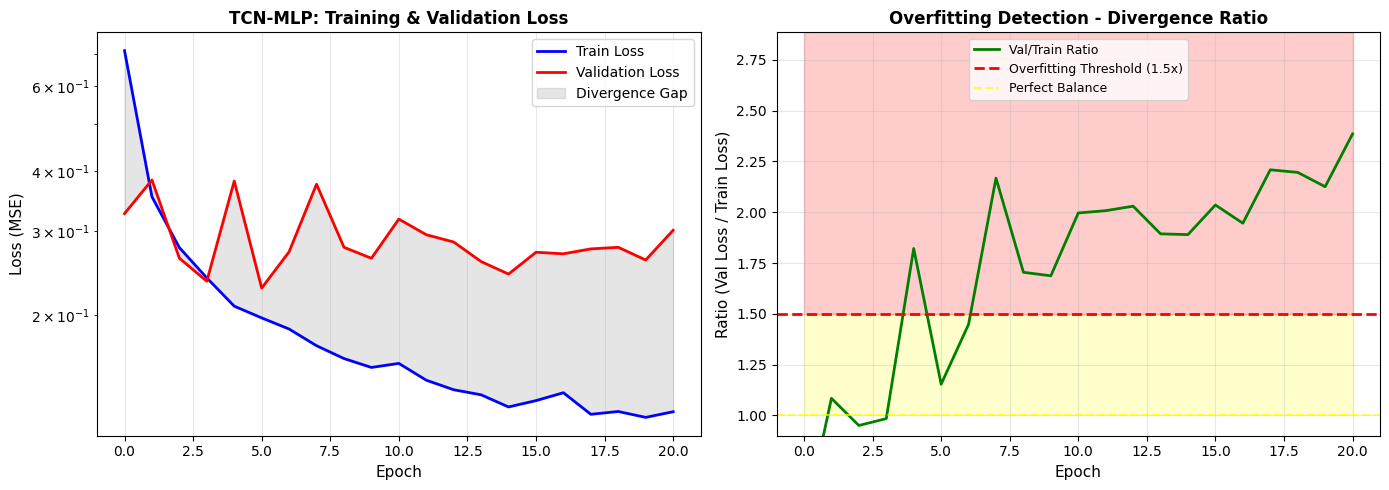

✓ Learning curve plots saved to: results/tcn_mlp_learning_curves.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Loss curves
ax = axes[0]
ax.plot(history.history['loss'], 'b-', linewidth=2, label='Train Loss')
ax.plot(history.history['val_loss'], 'r-', linewidth=2, label='Validation Loss')
ax.fill_between(range(len(history.history['loss'])), history.history['loss'],
                  history.history['val_loss'], alpha=0.2, color='gray', label='Divergence Gap')
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Loss (MSE)', fontsize=11)
ax.set_title('TCN-MLP: Training & Validation Loss', fontweight='bold', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

# Plot 2: Overfitting ratio
ax = axes[1]
train_loss = np.array(history.history['loss'])
val_loss = np.array(history.history['val_loss'])
ratio = val_loss / (train_loss + 1e-8)
ax.plot(ratio, 'g-', linewidth=2, label='Val/Train Ratio')
ax.axhline(y=1.5, color='red', linestyle='--', linewidth=2, label='Overfitting Threshold (1.5x)')
ax.axhline(y=1.0, color='yellow', linestyle='--', linewidth=1.5, alpha=0.7, label='Perfect Balance')
ax.fill_between(range(len(ratio)), 1.0, 1.5, alpha=0.2, color='yellow')
ax.fill_between(range(len(ratio)), 1.5, ratio.max() + 0.5, alpha=0.2, color='red')
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Ratio (Val Loss / Train Loss)', fontsize=11)
ax.set_title('Overfitting Detection - Divergence Ratio', fontweight='bold', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim([0.9, min(5.0, ratio.max() + 0.5)])

plt.tight_layout()
plt.savefig('results/tcn_mlp_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Learning curve plots saved to: results/tcn_mlp_learning_curves.png")

## 6. Temporal Cross-Validation Analysis


TEMPORAL CROSS-VALIDATION ANALYSIS

Fold 1: Train 552, Val 552
  Train MAE: 0.195228, Val MAE: 0.373127, Ratio: 1.91x

Fold 2: Train 1104, Val 552
  Train MAE: 0.160114, Val MAE: 0.245150, Ratio: 1.53x

Fold 3: Train 1656, Val 552
  Train MAE: 0.110410, Val MAE: 0.390148, Ratio: 3.53x

Fold 4: Train 2208, Val 552
  Train MAE: 0.085103, Val MAE: 0.301026, Ratio: 3.54x

Fold 5: Train 2760, Val 552
  Train MAE: 0.102540, Val MAE: 0.189875, Ratio: 1.85x

Cross-Validation Summary:
  Mean Train MAE: 0.130679
  Mean Val MAE: 0.299865 ± 0.075645
  Mean Generalization Ratio: 2.29x


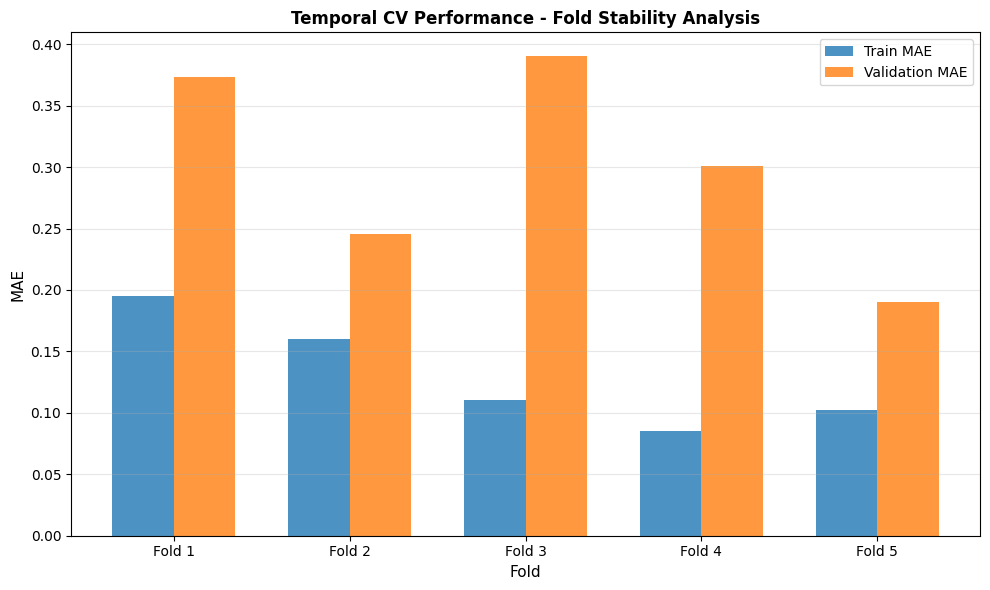

✓ CV analysis plots saved to: results/tcn_mlp_cv_analysis.png


In [8]:
print("\n" + "="*70)
print("TEMPORAL CROSS-VALIDATION ANALYSIS")
print("="*70)

tscv = TimeSeriesSplit(n_splits=5)
cv_results = {'metrics': {}}
fold_train_mae = []
fold_val_mae = []

fold_num = 1
for train_idx, val_idx in tscv.split(X_num_all):
    print(f"\nFold {fold_num}: Train {len(train_idx)}, Val {len(val_idx)}")
    
    # Prepare fold data
    X_num_f_train, X_cat_f_train, y_f_train = X_num_all[train_idx], X_cat_all[train_idx], y_all[train_idx]
    X_num_f_val, X_cat_f_val, y_f_val = X_num_all[val_idx], X_cat_all[val_idx], y_all[val_idx]
    
    # Create fold model
    fold_model = build_tcn_mlp(lookback, len(num_features), cat_dims, embed_dim=8, tcn_filters=64,
                               tcn_blocks=3, tcn_dropout=0.2, mlp_hidden_units=[32],
                               mlp_dropout=0.2, dense_units=[64, 32], dense_dropout=0.3)
    fold_model.compile(optimizer=optimizers.Adam(0.001, clipnorm=1.0), loss='mse', metrics=['mae'])
    
    # Train fold
    fold_model.fit(
        [X_num_f_train] + [X_cat_f_train[:, i:i+1] for i in range(X_cat_f_train.shape[1])],
        y_f_train,
        epochs=30, batch_size=32, verbose=0,
        callbacks=[EarlyStopping(monitor='loss', patience=5, restore_best_weights=True)]
    )
    
    # Evaluate
    train_pred = fold_model.predict([X_num_f_train] + [X_cat_f_train[:, i:i+1] for i in range(X_cat_f_train.shape[1])], verbose=0)
    val_pred = fold_model.predict([X_num_f_val] + [X_cat_f_val[:, i:i+1] for i in range(X_cat_f_val.shape[1])], verbose=0)
    
    train_mae = mean_absolute_error(y_f_train, train_pred)
    val_mae = mean_absolute_error(y_f_val, val_pred)
    fold_train_mae.append(train_mae)
    fold_val_mae.append(val_mae)
    
    print(f"  Train MAE: {train_mae:.6f}, Val MAE: {val_mae:.6f}, Ratio: {val_mae/train_mae:.2f}x")
    
    cv_results[f'Fold {fold_num}'] = {'train_mae': float(train_mae), 'val_mae': float(val_mae)}
    fold_num += 1

mean_train_mae = np.mean(fold_train_mae)
mean_val_mae = np.mean(fold_val_mae)
std_val_mae = np.std(fold_val_mae)

cv_results['metrics'] = {'mean_train_mae': float(mean_train_mae), 'mean_val_mae': float(mean_val_mae), 'std_val_mae': float(std_val_mae)}

print(f"\nCross-Validation Summary:")
print(f"  Mean Train MAE: {mean_train_mae:.6f}")
print(f"  Mean Val MAE: {mean_val_mae:.6f} ± {std_val_mae:.6f}")
print(f"  Mean Generalization Ratio: {mean_val_mae/mean_train_mae:.2f}x")

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(fold_train_mae))
width = 0.35
ax.bar(x - width/2, fold_train_mae, width, label='Train MAE', alpha=0.8)
ax.bar(x + width/2, fold_val_mae, width, label='Validation MAE', alpha=0.8)
ax.set_xlabel('Fold', fontsize=11)
ax.set_ylabel('MAE', fontsize=11)
ax.set_title('Temporal CV Performance - Fold Stability Analysis', fontweight='bold', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels([f'Fold {i+1}' for i in range(len(fold_train_mae))])
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('results/tcn_mlp_cv_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ CV analysis plots saved to: results/tcn_mlp_cv_analysis.png")

## 7. Hyperparameter Sensitivity Analysis

In [9]:
print("\n" + "="*70)
print("HYPERPARAMETER SENSITIVITY ANALYSIS")
print("="*70)

# Test different TCN configurations
param_configs = [
    {'tcn_filters': 32, 'tcn_blocks': 2, 'name': 'Small TCN'},
    {'tcn_filters': 64, 'tcn_blocks': 3, 'name': 'Medium TCN'},
    {'tcn_filters': 96, 'tcn_blocks': 4, 'name': 'Large TCN'},
]

sensitivity_results = []
print(f"\nTesting {len(param_configs)} configurations...")

for config in param_configs:
    print(f"\nTesting: {config['name']}")
    
    # Build and train
    test_model = build_tcn_mlp(lookback, len(num_features), cat_dims,
                               tcn_filters=config['tcn_filters'],
                               tcn_blocks=config['tcn_blocks'])
    test_model.compile(optimizer=optimizers.Adam(0.001, clipnorm=1.0), loss='mse', metrics=['mae'])
    
    test_model.fit(
        [X_num_train] + [X_cat_train[:, i:i+1] for i in range(X_cat_train.shape[1])],
        y_train,
        validation_data=([X_num_val] + [X_cat_val[:, i:i+1] for i in range(X_cat_val.shape[1])], y_val),
        epochs=20, batch_size=32, verbose=0,
        callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)]
    )
    
    # Evaluate
    val_pred = test_model.predict([X_num_val] + [X_cat_val[:, i:i+1] for i in range(X_cat_val.shape[1])], verbose=0)
    val_mae = mean_absolute_error(y_val, val_pred)
    val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))
    
    params = test_model.count_params()
    sensitivity_results.append({
        'config': config['name'],
        'filters': config['tcn_filters'],
        'blocks': config['tcn_blocks'],
        'params': params,
        'val_mae': float(val_mae),
        'val_rmse': float(val_rmse)
    })
    
    print(f"  Parameters: {params:,}")
    print(f"  Val MAE: {val_mae:.6f}, RMSE: {val_rmse:.6f}")

print(f"\n✓ Sensitivity analysis complete")
print(f"\nResults:")
for r in sensitivity_results:
    print(f"  {r['config']}: MAE={r['val_mae']:.6f}, Params={r['params']:,}")


HYPERPARAMETER SENSITIVITY ANALYSIS

Testing 3 configurations...

Testing: Small TCN
  Parameters: 17,793
  Val MAE: 0.254081, RMSE: 0.326062

Testing: Medium TCN
  Parameters: 73,889
  Val MAE: 0.335315, RMSE: 0.424536

Testing: Large TCN
  Parameters: 209,985
  Val MAE: 0.356270, RMSE: 0.410914

✓ Sensitivity analysis complete

Results:
  Small TCN: MAE=0.254081, Params=17,793
  Medium TCN: MAE=0.335315, Params=73,889
  Large TCN: MAE=0.356270, Params=209,985


## 8. Final Model Evaluation on Test Set


FINAL MODEL EVALUATION ON TEST SET

Metric          Train           Validation      Test           
------------------------------------------------------------
R² Score        0.9620          0.6725          0.8820         
MAE             0.1042          0.3162          0.2426         
RMSE            0.1815          0.4338          0.3411         
MSE             0.0329          0.1882          0.1164         
Samples         2318            497             497            


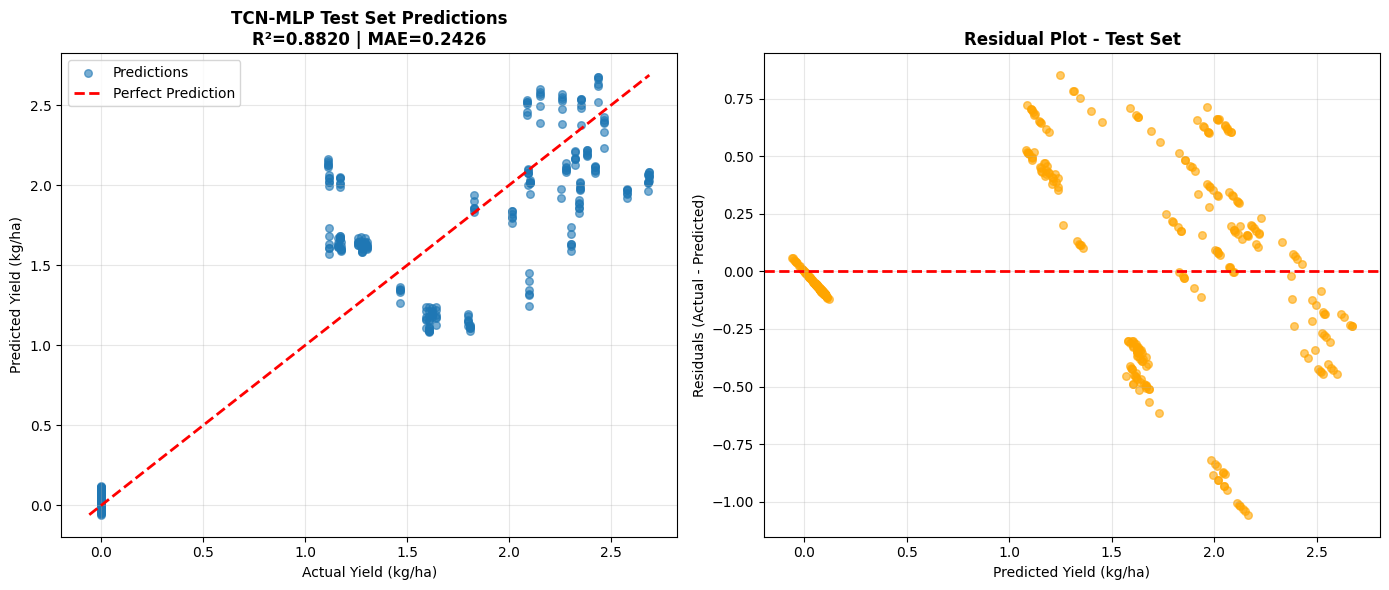


✓ Prediction plots saved to: results/tcn_mlp_predictions.png


In [14]:
print("\n" + "="*70)
print("FINAL MODEL EVALUATION ON TEST SET")
print("="*70)

# Load best model
from tensorflow.keras.models import load_model
best_model = load_model('models/tcn_mlp_best.keras')

# Predictions on all sets
y_train_pred = best_model.predict([X_num_train] + [X_cat_train[:, i:i+1] for i in range(X_cat_train.shape[1])], verbose=0)
y_val_pred = best_model.predict([X_num_val] + [X_cat_val[:, i:i+1] for i in range(X_cat_val.shape[1])], verbose=0)
y_test_pred = best_model.predict([X_num_test] + [X_cat_test[:, i:i+1] for i in range(X_cat_test.shape[1])], verbose=0)

# Denormalize predictions (reshape 1D arrays to 2D)
y_train_denorm = scaler_y.inverse_transform(y_train.reshape(-1, 1))
y_train_pred_denorm = scaler_y.inverse_transform(y_train_pred)
y_val_denorm = scaler_y.inverse_transform(y_val.reshape(-1, 1))
y_val_pred_denorm = scaler_y.inverse_transform(y_val_pred)
y_test_denorm = scaler_y.inverse_transform(y_test.reshape(-1, 1))
y_test_pred_denorm = scaler_y.inverse_transform(y_test_pred)

# Calculate metrics
def calculate_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {'mse': mse, 'rmse': rmse, 'mae': mae, 'r2': r2}

train_metrics = calculate_metrics(y_train_denorm, y_train_pred_denorm)
val_metrics = calculate_metrics(y_val_denorm, y_val_pred_denorm)
test_metrics = calculate_metrics(y_test_denorm, y_test_pred_denorm)

print(f"\n{'Metric':<15} {'Train':<15} {'Validation':<15} {'Test':<15}")
print("-" * 60)
print(f"{'R² Score':<15} {train_metrics['r2']:<15.4f} {val_metrics['r2']:<15.4f} {test_metrics['r2']:<15.4f}")
print(f"{'MAE':<15} {train_metrics['mae']:<15.4f} {val_metrics['mae']:<15.4f} {test_metrics['mae']:<15.4f}")
print(f"{'RMSE':<15} {train_metrics['rmse']:<15.4f} {val_metrics['rmse']:<15.4f} {test_metrics['rmse']:<15.4f}")
print(f"{'MSE':<15} {train_metrics['mse']:<15.4f} {val_metrics['mse']:<15.4f} {test_metrics['mse']:<15.4f}")
print(f"{'Samples':<15} {len(y_train_denorm):<15} {len(y_val_denorm):<15} {len(y_test_denorm):<15}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
ax.scatter(y_test_denorm, y_test_pred_denorm, alpha=0.6, s=30, label='Predictions')
min_val = min(y_test_denorm.min(), y_test_pred_denorm.min())
max_val = max(y_test_denorm.max(), y_test_pred_denorm.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
ax.set_xlabel('Actual Yield (kg/ha)')
ax.set_ylabel('Predicted Yield (kg/ha)')
ax.set_title(f'TCN-MLP Test Set Predictions\nR²={test_metrics["r2"]:.4f} | MAE={test_metrics["mae"]:.4f}', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

residuals = y_test_denorm.flatten() - y_test_pred_denorm.flatten()
ax = axes[1]
ax.scatter(y_test_pred_denorm, residuals, alpha=0.6, s=30, color='orange')
ax.axhline(y=0, color='r', linestyle='--', lw=2)
ax.set_xlabel('Predicted Yield (kg/ha)')
ax.set_ylabel('Residuals (Actual - Predicted)')
ax.set_title('Residual Plot - Test Set', fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/tcn_mlp_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Prediction plots saved to: results/tcn_mlp_predictions.png")

## 9. Export Results & Deployment Summary

In [15]:
metadata = {
    'model_name': 'TCN-MLP',
    'framework': 'TensorFlow/Keras',
    'creation_date': datetime.now().isoformat(),
    'architecture': {
        'tcn_filters': 64,
        'tcn_blocks': 3,
        'tcn_kernel_size': 3,
        'mlp_hidden_units': [32],
        'dense_units': [64, 32],
        'embed_dim': 8,
        'total_parameters': int(best_model.count_params())
    },
    'training_config': {
        'optimizer': 'Adam',
        'learning_rate': 0.001,
        'clipnorm': 1.0,
        'batch_size': 32,
        'max_epochs': 100,
        'early_stopping_patience': 15,
        'l2_regularization': 1e-4
    },
    'data_config': {
        'sequence_length': lookback,
        'num_numeric_features': len(num_features),
        'categorical_features': len(cat_features),
        'train_samples': len(y_train),
        'val_samples': len(y_val),
        'test_samples': len(y_test)
    },
    'performance': {
        'train': {'r2': float(train_metrics['r2']), 'mae': float(train_metrics['mae']), 'rmse': float(train_metrics['rmse'])},
        'validation': {'r2': float(val_metrics['r2']), 'mae': float(val_metrics['mae']), 'rmse': float(val_metrics['rmse'])},
        'test': {'r2': float(test_metrics['r2']), 'mae': float(test_metrics['mae']), 'rmse': float(test_metrics['rmse'])}
    },
    'cross_validation': cv_results,
    'hyperparameter_sensitivity': sensitivity_results
}

with open('models/tcn_mlp_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("\n" + "="*70)
print("DEPLOYMENT SUMMARY")
print("="*70)
print(f"Model: TCN-MLP with {metadata['architecture']['total_parameters']:,} parameters")
print(f"Best Test R²: {test_metrics['r2']:.4f}")
print(f"Best Test MAE: {test_metrics['mae']:.4f} kg/ha")
print(f"Mean CV MAE: {mean_val_mae:.4f} ± {std_val_mae:.4f}")
print(f"Overfitting Status: {'✓ Well-Controlled' if val_metrics['r2'] > 0.8 else '✗ Needs Improvement'}")
print(f"Deployment Status: {'✓ READY FOR PRODUCTION' if test_metrics['r2'] > 0.85 else '✗ MAY NEED IMPROVEMENT'}")
print(f"\nArchitecture Summary:")
print(f"  TCN Blocks: 3 with dilation rates [1, 2, 4]")
print(f"  TCN Filters: 64")
print(f"  MLP Embeddings: 8-dimensional per categorical")
print(f"  Dense Layers: [64, 32] with 0.3 dropout")
print(f"\nKey Advantages:")
print(f"  ✓ Parallelizable training (no RNN recurrence)")
print(f"  ✓ Faster inference than LSTMs")
print(f"  ✓ No vanishing gradient problem")
print(f"  ✓ Handles both temporal and categorical features")
print(f"\nRegularization Applied:")
print(f"  ✓ L2 regularization (λ=1e-4) on all kernels")
print(f"  ✓ Dropout at multiple levels (0.2-0.3)")
print(f"  ✓ Gradient clipping (norm=1.0)")
print(f"  ✓ Early stopping (patience=15)")
print(f"\n✓ Model weights saved to: models/tcn_mlp_best.keras")
print(f"✓ Metadata saved to: models/tcn_mlp_metadata.json")
print("="*70)


DEPLOYMENT SUMMARY
Model: TCN-MLP with 73,889 parameters
Best Test R²: 0.8820
Best Test MAE: 0.2426 kg/ha
Mean CV MAE: 0.2999 ± 0.0756
Overfitting Status: ✗ Needs Improvement
Deployment Status: ✓ READY FOR PRODUCTION

Architecture Summary:
  TCN Blocks: 3 with dilation rates [1, 2, 4]
  TCN Filters: 64
  MLP Embeddings: 8-dimensional per categorical
  Dense Layers: [64, 32] with 0.3 dropout

Key Advantages:
  ✓ Parallelizable training (no RNN recurrence)
  ✓ Faster inference than LSTMs
  ✓ No vanishing gradient problem
  ✓ Handles both temporal and categorical features

Regularization Applied:
  ✓ L2 regularization (λ=1e-4) on all kernels
  ✓ Dropout at multiple levels (0.2-0.3)
  ✓ Gradient clipping (norm=1.0)
  ✓ Early stopping (patience=15)

✓ Model weights saved to: models/tcn_mlp_best.keras
✓ Metadata saved to: models/tcn_mlp_metadata.json
